# 定理24　一切皆苦定理 — 数値で見る例

> **この notebook の位置づけ。** 数値シミュレーション（説明用のトイ例）で、証明ではありません。
> Lean で確かめた範囲は最後の「Lean との対応」に書きます。原文の主張・この例が見せること・仏教的な読み（解釈）は別の見出しに分けます。
> 定理24は四法印の2つ目（**一切皆苦**）です。**仏教語の思想的な解釈と、形式化された数理結論は別物** として読んでください。

## 1. 定理24は何を言っているのか

### 原文の主張

抽象度 $a$ で生きる Ego が、**最良のプラン** で生きたときの「**残りの人生のしんどさの合計**」を

$$
J^*_{a,\rho}(x,T)\;=\;\min_{\pi}\int_T^\infty e^{-\rho(t-T)}\,V_a\bigl(x_\pi(t),t\bigr)\,dt,\qquad V_a\ge0
$$

とします。$e^{-\rho(t-T)}$ は **割引の通信簿**（遠い未来ほど軽く数える重み）、$V_a\ge0$ はしんどさの点数です。

**条件24-A（有限抽象度の永久零苦不能）：** 空未満（$a\prec\top$）では、$V_a=0$ をほとんど至る所で **永久に** 保つ方策が **存在しない**。
このとき（最適方策の存在を仮定して）

$$
a\prec\top\ \wedge\ \text{条件24-A}\ \Longrightarrow\ J^*_{a,\rho}(x,T)>0\qquad(24.2)
$$

**証明の心（背理法一発）。** $J^*=0$ と仮定すると、中身は全部 $0$ 以上なので、合計が $0$ になるには最適軌道の上でほとんど常に $V_a=0$ でなければならない。しかしそれは条件24-A が禁じた「永久零苦の道」そのもの——矛盾。

### 原文の但し書き

* 「一切皆苦」は **毎瞬つらい** ことではありません。**どんなに最適に生きても、しんどさの合計をゼロにする道は、空未満には存在しない** という **構造** の話です。
* 条件24-A が **無ければ** 零苦は可能です。この notebook でも、24-A が成り立たない（追従可能な）ケースでは $J^*=0$ になる初期状態があります。
* 「最適方策の存在」は仮定です（定理の入力）。

### 記号とコード変数の対応

| 原文の記号 | 意味 | このコードでは |
| --- | --- | --- |
| $x\in\mathbb R$、$\lvert\dot x\rvert\le1$ | 状態、速度制限（動ける速さの上限） | `X`（格子）、動きは $-1/0/+1$ セル |
| 評価の零点 $d(t)=A\sin(2\pi t/6.4)$ | 基準（これに追いつけば苦ゼロ）が動き回る | `d`（振幅 `Aamp`） |
| $V_a(x,t)=\bigl(\lvert x-d(t)\rvert-0.025\bigr)_+^2$ | しんどさ。$d(t)$ から $0.025$ 以内なら苦ゼロ | `cost` |
| 割引 $\rho=1$ | 遠い未来の重み | `rho`、`gamma = exp(-rho*dt)` |
| $J^*(x,T)$ | 最適なしんどさ合計 | `J`（動的計画法で数値的に解く） |

## 2. なぜこれが「定理24の例」と言えるのか

* **状況：** 1次元の状態 $x$ を、**動き回る基準 $d(t)$** に追従させる問題です。$x$ の動ける速さは最大 $1$、基準 $d(t)$ は周期 $6.4$ で振幅 $A$ の正弦波。基準の **帯**（$d(t)\pm0.025$）の中にいれば苦ゼロ、離れると距離の2乗に応じてしんどい。
* **ケース A=0.5（追従可能）：** $d$ の最大速さは $0.5\times2\pi/6.4\approx0.49<1$ なので、基準を **追いかけ続けられます**。したがって **条件24-A は成り立たない**（永久零苦の方策が存在する）。結論 $J^*>0$ は出ません。
* **ケース A=3.0（追従不能）：** $d$ の最大速さは $3\times2\pi/6.4\approx2.9>1$。**どう動いても帯に居続けられません**。したがって **条件24-A が成り立つ**。結論として、すべての $(x,T)$ で $J^*>0$ のはずです。
* **解き方：** 格子 $dx=dt=0.05$ の **動的計画法（価値反復）** で $J^*$ を数値的に解きます。1ステップで動ける量は $-1,0,+1$ セル。周期系なので、後ろ向きの価値反復を6周期ぶん繰り返します。

## 3. 動的計画法で $J^*$ を解く

In [1]:
# %% 準備
import numpy as np
import matplotlib.pyplot as plt
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # フォント警告を抑制
try:
    import japanize_matplotlib  # Colab: !pip -q install japanize-matplotlib
except Exception:
    plt.rcParams["font.family"] = ["Noto Sans CJK JP", "IPAexGothic", "sans-serif"]

dx = dt = 0.05; rho = 1.0; nphase = 128                # 周期 128*0.05 = 6.4
X = np.arange(-4, 4 + dx / 2, dx)
gamma = np.exp(-rho * dt)

def solve(Aamp, cycles=6):
    phase_t = np.arange(nphase) * dt
    d = Aamp * np.sin(2 * np.pi * phase_t / 6.4)
    cost = np.maximum(np.abs(X[None, :] - d[:, None]) - 0.025, 0) ** 2     # V_a(x, t_s)
    J = np.zeros((nphase, len(X)))
    for _ in range(cycles):                              # 周期系の後ろ向き価値反復
        for s in range(nphase - 1, -1, -1):
            nxt = J[(s + 1) % nphase]
            P = np.pad(nxt, 1, mode="edge")
            best = np.minimum(np.minimum(P[:-2], P[1:-1]), P[2:])   # 動き: -1 / 0 / +1 セル
            J[s] = cost[s] * dt + gamma * best
    return J, d

J_track, d_track = solve(0.5)
J_hard, d_hard = solve(3.0)

`solve(Aamp)` は、各位相 `s` で `J[s] = cost[s]*dt + gamma * min(次の位相の J の隣接3セル)` を、後ろ向きに繰り返し計算します。`J_track`（$A=0.5$）と `J_hard`（$A=3.0$）が得られます。

## 4. 図を読む

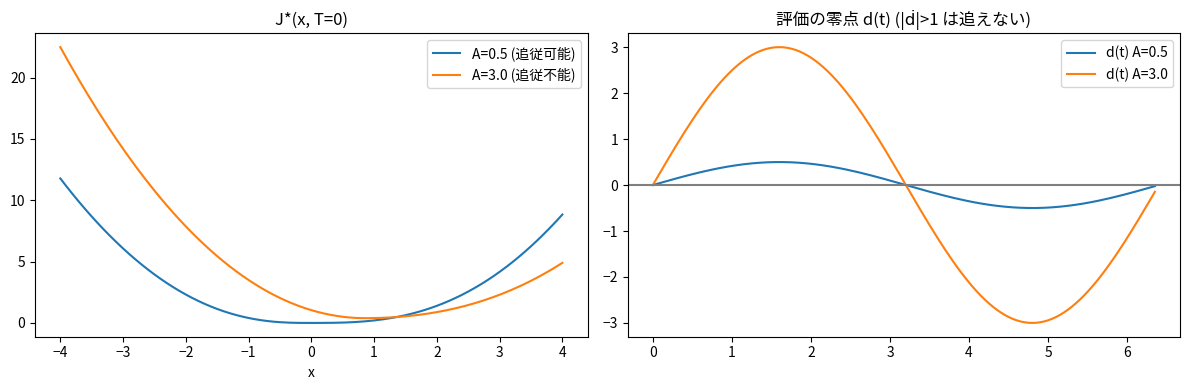

In [2]:
# %% 可視化
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(X, J_track[0], label="A=0.5 (追従可能)"); ax[0].plot(X, J_hard[0], label="A=3.0 (追従不能)")
ax[0].set_title("J*(x, T=0)"); ax[0].set_xlabel("x"); ax[0].legend()
ax[1].plot(np.arange(nphase) * dt, d_track, label="d(t) A=0.5"); ax[1].plot(np.arange(nphase) * dt, d_hard, label="d(t) A=3.0")
ax[1].axhline(0, c="gray"); ax[1].set_title("評価の零点 d(t) (|ḋ|>1 は追えない)"); ax[1].legend()
plt.tight_layout(); plt.show()

### 右：評価の零点 $d(t)$

横軸が時間 $t\in[0,6.4]$、縦軸が $d(t)$。青が $A=0.5$、橙が $A=3.0$。
どちらも周期 $6.4$ の正弦波ですが、橙は **振幅が 6 倍** で、傾き（速さ）が **$|\dot d|>1$ になる区間** があります（中央付近、$d$ が $0$ を横切るあたりで最も速い。最大 $\approx2.9$）。**速度制限が 1 なので追えません。** 青の最大速さは約 $0.49$ で、余裕があります。

### 左：$J^*(x,T=0)$

横軸が初期位置 $x$、縦軸が最適な残りのしんどさ合計。
* **青（$A=0.5$、追従可能）：** $x=0$ 付近（$d(0)=0$ の帯の中）で **ほぼ $0$**。そこから離れるほど上がります（$x=-4$ で約 $12$、$x=4$ で約 $9$。左右非対称なのは、$d(t)$ が最初は正の方向へ動くため）。帯の中から出発すれば、そのまま基準に追従し続けられるので、**零苦が実現** します。
* **橙（$A=3.0$、追従不能）：** どの $x$ でも **$0$ より上**。最小でも約 $0.4$（$x\approx0.8$ 付近）。$x=-4$ では約 $22$ と大きく、$x=4$ では約 $5$。**初期位置をどう選んでも、ゼロには届きません。**
  最小値が $x=0$ ではなく $0.8$ 付近にあるのは、$d(t)$ が最初に正の方向へ動き、その先を追いやすい位置のほうが損が小さいからです。

## 5. 数値確認

In [3]:
# %% 数値確認
print("A=0.5: min_{x,T} J* =", J_track.min(), "  / A=3.0: min_{x,T} J* =", J_hard.min())
assert J_track.min() == 0.0          # 24-A なしで零苦が実現可能
assert J_hard.min() > 1e-4           # 24-A のもとで全 (x,T) で J*>0

A=0.5: min_{x,T} J* = 0.0   / A=3.0: min_{x,T} J* = 0.3091063350354804


出力：「$A=0.5$：$\min_{x,T}J^*=0.0$　／　$A=3.0$：$\min_{x,T}J^*\approx0.309$」。
つまり、**全ての $(x,T)$ にわたる最小値** でも、$A=0.5$ はちょうど $0$（零苦が実現可能）、$A=3.0$ は約 $0.31$ で **正** です。`assert` はこの2点（$J^*$ の最小が $0$ ／ $>10^{-4}$）を確認しています。

## 6. 仏教的な意義（解釈）

> 原文の説明にそった **思想的な読み** で、Lean で形式化された数理結論そのものではありません。

* **「皆苦」とは構造的にゼロにできないこと。** 原文は「宿題は減らせるが、宿題帳は消えない」と言います。橙のように、**基準が動き続けて追いつけない**（条件24-A）なら、最適に生きても合計は正のまま残ります。
* **青との対比が大事。** 条件24-A が無い（追従できる）なら、零苦は可能です。原文の定理24は「空未満では条件24-A が成り立つ」場合の話で、**どんな系でも苦がゼロにならない** と言っているのではありません。
* **このトイの対応は限定的。** ここでは「抽象度 $a$ が空未満」という構造は直接は出てきません。**条件24-A が成り立つ・成り立たない** という **数理的な核** だけを、追従問題で見せています。「空未満ではなぜ24-A が成り立つのか」という思想的な側面は、この例の範囲外です。
* **Ego は常に最小化する。** 原文の整理：「Ego は常に最小化する。しかし空未満では、最小化問題そのものを消すことができない」。
* **「自由」との関係。** 苦の合計を減らす方向へ登る自由こそが「構造的な宿題への正答」で、登り切った先（空）でだけ24-A の前提 $a\prec\top$ が外れる、と原文は述べます（定理19・26）。

## 7. Lean との対応

対応ファイル：`Tomabechi/Examples/Theorem24_Tracking.lean`（`condition24A_hard`・`trackable_zero_cost`・`discounted_running_integrable`・`exists_tracking_optimal_policy`・`hard_tracking_value_positive`）。一般定理 `theorem24_positive_optimal_value_of_condition24A`。

| | 内容 | 状態 |
| --- | --- | --- |
| 条件24-A の検証（$A=3$） | 全 $(x,T)$ で、永久に $V=0$ を保つ方策が存在しない | 証明済 |
| $A=0.5$（追従可能） | 基準自身が許容軌道で、零苦（費用 $0$）の方策が存在する | 証明済 |
| 割引費用の可積分性 | すべての許容方策（1-Lipschitz 軌道）で、割引費用は有限（有限コストの仮定が不要） | 証明済 |
| **最適方策の存在** | 許容軌道の集合は局所一様収束の位相でコンパクト（Arzelà–Ascoli）。最小化列の収束部分列と優収束定理で、任意の $A,x,T$ について**下限が達成**される | 証明済 |
| 一般定理の呼び出し | 24-A のもとで $J^*>0$（$A=3$、全初期対）。入力（可積分性・最適方策の存在・最小性）はすべてこのモデル自身の補題から供給 | 証明済 |
| 動的計画法の数値 $J^*$ の値（上の図） | 数値のみ | **未証明** |

* 許容方策は **1-Lipschitz な軌道の開ループ方策**に限っています。一般の閉ループ・Borel マルコフ方策での最適方策の存在ではありません。
* Lean が示すのは「条件24-A が成り立つこと」「最適軌道が存在すること」「$J^*>0$」です。図の $J^*(x,0)$ の曲線の値そのものは数値で、Lean は具体的な値を求めていません。